# (노트) ImagaeDataLoaders
> 완성 

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [fastai, 딥러닝]

In [88]:
from fastai.data.all import * 
from fastai.vision.all import * 

### Path

`-` Path 클래스는 시스템에 따라서 PosixPath 혹은 WindowsPath 오브젝트를 반환한다. 

In [89]:
path=Path() # Path클래스로 부터 인스턴스 생성

In [90]:
path # 현재경로 확인

Path('.')

In [91]:
# path의 type확인: 우리는 우분투를 사용하므로 PosixPath 타입이다. 
path?

Type:        PosixPath
String form: .
File:        ~/anaconda3/envs/2021bda/lib/python3.8/pathlib.py
Docstring:  
Path subclass for non-Windows systems.

On a POSIX system, instantiating a Path should return this object.


`-` .ls() 메소드를 통하여 path에 저장된 파일목록을 볼 수 있다. 

In [92]:
path.ls()

(#155) [Path('2019-05-20-(리뷰) Shuman2012의 레퍼런스 정리 [기하학적 딥러닝].ipynb'),Path('2021-08-09-(연구) HST example 2 이거로하자 [기하학적 딥러닝, 논문연구].ipynb'),Path('2021-08-28-(노트) Second CNN [파이토치].ipynb'),Path('2020-10-07-(샘플) tibble 선언 [R].ipynb'),Path('2021-08-02-(연구) HST example 1 (3) [기하학적 딥러닝, 논문연구].ipynb'),Path('2020-09-03-(노트) plt.plot [파이썬].ipynb'),Path('2021-05-17-(노트) 다층퍼셉트론, XOR 분류문제의 해결 [딥러닝].ipynb'),Path('2018-01-01-(노트) julia 설치 [우분투].ipynb'),Path('2021-08-15-MCU-weights.csv'),Path('2021-08-03-(노트) Pytorch Fashion-MNIST [파이토치, 딥러닝].ipynb')...]

- 사실 이 메소드는 원래 `pathlib`에서 제공하는 기능이 아니라 fastai/data에서 새롭게 추가한 메소드다. 

`-` .ls()메소드에서 반환되는것은 `L`타입의 자료이다. 

In [93]:
a=path.ls()
a?

Type:        L
String form: [Path('2019-05-20-(리뷰) Shuman2012의 레퍼런스 정리 [기하학적 딥러닝].ipynb'), Path('2021-08-09-(연구) HST example  <...> ith tensorflow [텐서플로우].ipynb'), Path('2021-08-02-(연구) HST example 1 (4) [기하학적 딥러닝, 논문연구].ipynb')]
Length:      155
File:        ~/anaconda3/envs/2021bda/lib/python3.8/site-packages/fastcore/foundation.py
Docstring:   Behaves like a list of `items` but can also index with list of indices or masks


`-` Path(...) 에서 ...에 무엇을 넣느냐에 따라서 원하는 경로를 설정할 수 있다. 

In [94]:
### 예제1: 최상위경로 
Path('/').ls()

(#25) [Path('/libx32'),Path('/srv'),Path('/lib64'),Path('/etc'),Path('/home'),Path('/media'),Path('/sbin'),Path('/boot'),Path('/opt'),Path('/sys')...]

In [95]:
### 예제2 bin
Path('/bin').ls()

(#1501) [Path('/bin/rev'),Path('/bin/aptdcon'),Path('/bin/obexctl'),Path('/bin/startx'),Path('/bin/mscompress'),Path('/bin/chvt'),Path('/bin/hp-check'),Path('/bin/sane-find-scanner'),Path('/bin/Xorg'),Path('/bin/rcp')...]

In [96]:
### 예제3: Path('/bin') 와 Path('/bin/')은 같은결과임
Path('/bin/').ls()

(#1501) [Path('/bin/rev'),Path('/bin/aptdcon'),Path('/bin/obexctl'),Path('/bin/startx'),Path('/bin/mscompress'),Path('/bin/chvt'),Path('/bin/hp-check'),Path('/bin/sane-find-scanner'),Path('/bin/Xorg'),Path('/bin/rcp')...]

In [97]:
### 예제4 home
Path('/home').ls()

(#1) [Path('/home/cgb4')]

In [98]:
### 예제5 home/cgb4
Path('/home/cgb4').ls()

(#38) [Path('/home/cgb4/.rstudio'),Path('/home/cgb4/.jupyter'),Path('/home/cgb4/.local'),Path('/home/cgb4/.nv'),Path('/home/cgb4/.R'),Path('/home/cgb4/blacklist-nouveau.conf'),Path('/home/cgb4/Dropbox'),Path('/home/cgb4/.profile'),Path('/home/cgb4/.bashrc'),Path('/home/cgb4/.ipython')...]

In [99]:
### 예제6 home/cgb4/Dropbox
Path('/home/cgb4/Dropbox').ls()

(#22) [Path('/home/cgb4/Dropbox/08_apply'),Path('/home/cgb4/Dropbox/test.zip'),Path('/home/cgb4/Dropbox/지출목록.xlsx'),Path('/home/cgb4/Dropbox/.dropbox'),Path('/home/cgb4/Dropbox/모유수유표.xlsx'),Path('/home/cgb4/Dropbox/99_temp'),Path('/home/cgb4/Dropbox/01_yechan'),Path('/home/cgb4/Dropbox/03_projects'),Path('/home/cgb4/Dropbox/05_papers'),Path('/home/cgb4/Dropbox/02_library')...]

- Path('/bin') 와 Path('/bin/')은 같은결과임

`-` PosixPath 타입과 string을 `/` 연산자로 연결하여 새로운 경로의 PosixPath 를 얻을 수 있다. 

In [100]:
Path('/home').ls()

(#1) [Path('/home/cgb4')]

In [101]:
(Path('/')/'home').ls()

(#1) [Path('/home/cgb4')]

`-` .mkdir()을 통하여 폴더를 만들 수 있다. 

In [102]:
path_dropbox=Path('/home/cgb4/Dropbox')

In [103]:
path_dropbox.ls()

(#22) [Path('/home/cgb4/Dropbox/08_apply'),Path('/home/cgb4/Dropbox/test.zip'),Path('/home/cgb4/Dropbox/지출목록.xlsx'),Path('/home/cgb4/Dropbox/.dropbox'),Path('/home/cgb4/Dropbox/모유수유표.xlsx'),Path('/home/cgb4/Dropbox/99_temp'),Path('/home/cgb4/Dropbox/01_yechan'),Path('/home/cgb4/Dropbox/03_projects'),Path('/home/cgb4/Dropbox/05_papers'),Path('/home/cgb4/Dropbox/02_library')...]

In [104]:
(path_dropbox/'0000asdf').mkdir()

In [105]:
path_dropbox.ls()

(#23) [Path('/home/cgb4/Dropbox/0000asdf'),Path('/home/cgb4/Dropbox/08_apply'),Path('/home/cgb4/Dropbox/test.zip'),Path('/home/cgb4/Dropbox/지출목록.xlsx'),Path('/home/cgb4/Dropbox/.dropbox'),Path('/home/cgb4/Dropbox/모유수유표.xlsx'),Path('/home/cgb4/Dropbox/99_temp'),Path('/home/cgb4/Dropbox/01_yechan'),Path('/home/cgb4/Dropbox/03_projects'),Path('/home/cgb4/Dropbox/05_papers')...]

- 새로운 디렉토리를 만들때에는 `/`연산자를 사용해서 (path_dropbox/'0000asdf')와 같이 새로운 path를 만든 뒤에 .mkdir() 메소드를 사용한다. 

- Warninig: path_dropbox.mkdir('/0000asdf')는 동작하지 않음 

`-` .rmdir()을 활용하여 만든폴더를 지울수도 있다. 

In [106]:
(path_dropbox/'0000asdf').rmdir()

In [107]:
path_dropbox.ls()

(#22) [Path('/home/cgb4/Dropbox/08_apply'),Path('/home/cgb4/Dropbox/test.zip'),Path('/home/cgb4/Dropbox/지출목록.xlsx'),Path('/home/cgb4/Dropbox/.dropbox'),Path('/home/cgb4/Dropbox/모유수유표.xlsx'),Path('/home/cgb4/Dropbox/99_temp'),Path('/home/cgb4/Dropbox/01_yechan'),Path('/home/cgb4/Dropbox/03_projects'),Path('/home/cgb4/Dropbox/05_papers'),Path('/home/cgb4/Dropbox/02_library')...]

`-` .name()을 활용하여 최종 폴더 혹은 파일명을 단순 string으로 반환할수 있다. 

In [176]:
path_dropbox.name # 폴더명 리턴

'Dropbox'

In [177]:
(path_dropbox/'지출목목.xlsx').name # 파일명 리턴

'지출목목.xlsx'

### untar_data()

`-` untar_data는 fastai/data 에 소속된 함수임

In [108]:
### fastai/data 에 소속되었음을 확인
untar_data??

Signature:
untar_data(
    url,
    archive=None,
    data=None,
    c_key='data',
    force_download=False,
)
Source:   
def untar_data(url, archive=None, data=None, c_key='data', force_download=False):#, extract_func=file_extract, timeout=4):
    "Download `url` to `fname` if `dest` doesn't exist, and extract to folder `dest`"
    d = FastDownload(fastai_cfg(), module=fastai.data, archive=archive, data=data, base='~/.fastai')
    return d.get(url, force=force_download, extract_key=c_key)
File:      ~/anaconda3/envs/2021bda/lib/python3.8/site-packages/fastai/data/external.py
Type:      function


`-` 주요기능: 입력으로 압축파일을 다운받을 수 있는 url을 받으면 (1) 파일을 다운받아 '~/.fastai'에 압축을 풀고 (2) 해당경로를 PosixPath 자료형으로 반환한다. 

In [109]:
path = untar_data('https://s3.amazonaws.com/fast-ai-imageclas/oxford-iiit-pet.tgz')

In [110]:
path

Path('/home/cgb4/.fastai/data/oxford-iiit-pet')

> 압축푼 폴더이름은 압축파일이름과 같음

### get_image_files()

`-` fastai/data에 있는 함수

In [111]:
## fastai에서 만든 함수임을 확인
get_image_files??

Signature: get_image_files(path, recurse=True, folders=None)
Source:   
def get_image_files(path, recurse=True, folders=None):
    "Get image files in `path` recursively, only in `folders`, if specified."
    return get_files(path, extensions=image_extensions, recurse=recurse, folders=folders)
File:      ~/anaconda3/envs/2021bda/lib/python3.8/site-packages/fastai/data/transforms.py
Type:      function


`-` get_image_files(): 이미지폴더의 path $\to$ 폴더내의모든 이미지파일의 path의 묶음

입력: 이미지 파일이 저장된 폴더의 path 

출력: 입력폴더안에서 이미지파일로 판단되는 (확장자가 .jpg 등으로 끝나는) 모든파일의 path를 모은 list. 자료형은 list대신 L을 사용함. 

In [112]:
### untar_data()가 반환한 path재활용 
path

Path('/home/cgb4/.fastai/data/oxford-iiit-pet')

In [113]:
path.ls() # 이 path에는 크게 annotations 폴더와 image 폴더가 있음.

(#2) [Path('/home/cgb4/.fastai/data/oxford-iiit-pet/annotations'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images')]

In [114]:
(path/'images').ls() # image 폴더로 이동하여 목록을 확인한다. -> 다수의 그림파일 발견 (7395개)

(#7395) [Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/staffordshire_bull_terrier_106.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/english_cocker_spaniel_170.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/leonberger_5.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/shiba_inu_209.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/american_pit_bull_terrier_104.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/Egyptian_Mau_5.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/Egyptian_Mau_224.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/miniature_pinscher_58.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/american_bulldog_209.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/Persian_85.jpg')...]

In [115]:
get_image_files(path/'images') # 입력: PosixPath 타입, 출력: L 타입

(#7390) [Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/staffordshire_bull_terrier_106.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/english_cocker_spaniel_170.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/leonberger_5.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/shiba_inu_209.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/american_pit_bull_terrier_104.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/Egyptian_Mau_5.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/Egyptian_Mau_224.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/miniature_pinscher_58.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/american_bulldog_209.jpg'),Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/Persian_85.jpg')...]

In [116]:
get_image_files(path/'images')[0] # 첫번째 이미지가 저장된 path

Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/staffordshire_bull_terrier_106.jpg')

### ImageDataLoaders.from_name_func()

In [293]:
ImageDataLoaders.from_name_func??

Signature:
ImageDataLoaders.from_name_func(
    path,
    fnames,
    label_func,
    valid_pct=0.2,
    seed=None,
    item_tfms=None,
    batch_tfms=None,
    bs=64,
    val_bs=None,
    shuffle=True,
    device=None,
)
Source:   
    @classmethod
    def from_name_func(cls, path, fnames, label_func, **kwargs):
        "Create from the name attrs of `fnames` in `path`s with `label_func`"
        if sys.platform == 'win32' and isinstance(label_func, types.LambdaType) and label_func.__name__ == '<lambda>':
            # https://medium.com/@jwnx/multiprocessing-serialization-in-python-with-pickle-9844f6fa1812
            raise ValueError("label_func couldn't be lambda function on Windows")
        f = using_attr(label_func, 'name')
        return cls.from_path_func(path, fnames, f, **kwargs)
File:      ~/anaconda3/envs/2021bda/lib/python3.8/site-packages/fastai/vision/data.py
Type:      method


`-` Dataset, Datasets, Dataloader, Dataloaders 의 개념을 알아야함. 

`-` fastat/data에 있는 클래스, 주요기능은 Datasets와 DataLoaders를 만드는 것이다.

In [117]:
# fastai에서 제공하는 클래스임을 확인 + Docstring에서 주요기능 확인
DataBlock?

Init signature:
DataBlock(
    blocks=None,
    dl_type=None,
    getters=None,
    n_inp=None,
    item_tfms=None,
    batch_tfms=None,
    *,
    get_items=None,
    splitter=None,
    get_y=None,
    get_x=None,
)
Docstring:      Generic container to quickly build `Datasets` and `DataLoaders`
File:           ~/anaconda3/envs/2021bda/lib/python3.8/site-packages/fastai/data/block.py
Type:           type
Subclasses:     


- `blocks`: X와 y가 무엇이냐 
- 데이터가 위치한 폴더는 어디냐? 
- `get_item`: observation을 얻기위해 사용할 것은? 
- `get_y`: $y$에 적용할 전처리가 있는가? 
- `get_x`: $X$에 적용할 전처리가 있는가?
- `splitter`: 데이터를 분할하는 방법? 
- `item_tfms`: 형성된 항목에 무언가를 적용하는가?
- 형성된 배치에 무언가를 적용하는가? 

### Datasets

`-` 만드는법1: DataBlock instance 애서 .datasets()메서드를 사용하면 만들 수 있다. 

In [261]:
dblock = DataBlock() # 데이터블락 인스턴스 만듬

In [262]:
dblock.datasets(get_image_files(path/'images')[0:5]) # dblock인스턴스를 만들면 datasets라는 인스턴스 메소드를 활용하여 datasets을 만들수 있다: 우선 5개의 이미지(=5개의 데이터셋)로만 데이터셋츠구성

(#5) [(Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/staffordshire_bull_terrier_106.jpg'), Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/staffordshire_bull_terrier_106.jpg')),(Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/english_cocker_spaniel_170.jpg'), Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/english_cocker_spaniel_170.jpg')),(Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/leonberger_5.jpg'), Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/leonberger_5.jpg')),(Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/shiba_inu_209.jpg'), Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/shiba_inu_209.jpg')),(Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/american_pit_bull_terrier_104.jpg'), Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/american_pit_bull_terrier_104.jpg'))]

- Note: 보는것처럼 .datasets()는 path들의 리스트를 입력으로 받는다. 

In [263]:
dsets = dblock.datasets(get_image_files(path/'images')[0:5]) 

In [264]:
dsets?

Type:        Datasets
String form: (#5) [(Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/staffordshire_bull_terrier_106.jpg'), <...> jpg'), Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/american_pit_bull_terrier_104.jpg'))]
Length:      5
File:        ~/anaconda3/envs/2021bda/lib/python3.8/site-packages/fastai/data/core.py
Docstring:   A dataset that creates a tuple from each `tfms`, passed through `item_tfms`


`-` datasets는 dataset의 집합이다. 여기에는 5개의 자료가 있으므로 datasets는 5개의 dataset의 집합이라고 생각할 수 있다. 

In [265]:
dsets[0],dsets[1],dsets[2],dsets[3],dsets[4] # datasets에 소속된 5개의 dataset

((Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/staffordshire_bull_terrier_106.jpg'),
  Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/staffordshire_bull_terrier_106.jpg')),
 (Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/english_cocker_spaniel_170.jpg'),
  Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/english_cocker_spaniel_170.jpg')),
 (Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/leonberger_5.jpg'),
  Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/leonberger_5.jpg')),
 (Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/shiba_inu_209.jpg'),
  Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/shiba_inu_209.jpg')),
 (Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/american_pit_bull_terrier_104.jpg'),
  Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/american_pit_bull_terrier_104.jpg')))

`-` 각각의 dataset은 $(x_i,y_i)$를 의미한다. datasets는 $(x_1,y_1),\dots,(x_n,y_n)$을 의미한다. 

${\tt dsets[0]}:=(x_1,y_1), \dots , {\tt dsets[4]}:=(x_5,y_5)$

${\tt dsets}:=\big\{(x_i,y_i) \big\}_{i=1}^{5}$

`-` 예제의 경우 첫번째 dataset이 아래와 같다. 

In [266]:
dsets[0]

(Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/staffordshire_bull_terrier_106.jpg'),
 Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/staffordshire_bull_terrier_106.jpg'))

이것은 

$x_i=y_i=$`staffordshire_bull_terrier_106.jpg`에 저장된 이미지 

를 의미한다. 그러니까 $y_i$가 사실 잘못지정되어있다. 

`-` 원하는 것은 

$x_i=$`staffordshire_bull_terrier_106.jpg`에 저장된 이미지

$y_i=dog$

이다. 

In [269]:
dsets[0][0]

Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/staffordshire_bull_terrier_106.jpg')

In [268]:
dsets[0][1]

Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/staffordshire_bull_terrier_106.jpg')

`-` 아래와 같은 함수를 만들어서 dsets[i]의 두번째 원소에 전달하고 싶다. 

In [267]:
def label_func(fpath):
    return "cat" if fpath.name[0].isupper() else "dog"

TransformBlock
- CategoryBlock
- MultiCategoryBlock
- RegressionBlock 

`-` 아래와 같이 하면 된다. 

In [272]:
dblock = DataBlock(get_y=label_func)
dsets = dblock.datasets(get_image_files(path/'images')[0:5])
dsets

(#5) [(Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/staffordshire_bull_terrier_106.jpg'), 'dog'),(Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/english_cocker_spaniel_170.jpg'), 'dog'),(Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/leonberger_5.jpg'), 'dog'),(Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/shiba_inu_209.jpg'), 'dog'),(Path('/home/cgb4/.fastai/data/oxford-iiit-pet/images/american_pit_bull_terrier_104.jpg'), 'dog')]

In [ ]:
ImageDataLoaders.from_path_re

`-` 만드는법2: 

In [274]:
dblock = DataBlock(get_y=label_func,
                  blocks=(ImageBlock,_))
dsets = dblock.datasets(get_image_files(path/'images')[0:5])
dsets

(#5) [(PILImage mode=RGB size=333x500, 'dog'),(PILImage mode=RGB size=500x334, 'dog'),(PILImage mode=RGB size=493x500, 'dog'),(PILImage mode=RGB size=500x375, 'dog'),(PILImage mode=RGB size=500x333, 'dog')]

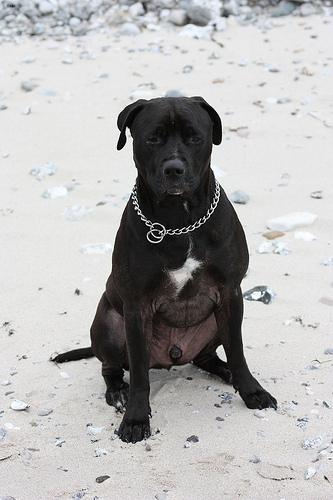

In [277]:
dsets[0][0]

In [278]:
dsets[0][1]

'dog'

In [279]:
dsets[0][0],dsets[0][1]

(PILImage mode=RGB size=333x500, 'dog')

`-` 만드는법3

In [281]:
dblock = DataBlock(get_y=label_func,
                  blocks=(ImageBlock,CategoryBlock))
dsets = dblock.datasets(get_image_files(path/'images')[0:5])
dsets[0]

(PILImage mode=RGB size=333x500, TensorCategory(0))

In [285]:
dls=dsets.dataloaders()

Could not do one pass in your dataloader, there is something wrong in it


In [289]:
dsets.sum

(#2) [[noop:
encodes: (object,object) -> noopdecodes: , PILBase.create:
encodes: (Path,object) -> create
(str,object) -> create
(Tensor,object) -> create
(ndarray,object) -> create
(bytes,object) -> createdecodes: ],label_func:
encodes: (object,object) -> label_funcdecodes: ]

In [288]:
dls.show_batch(max_n=4)

ValueError: This DataLoader does not contain any batches